#  Machine Learning: Dự Đoán Sự Hài Lòng Của Khách Hàng (Customer Satisfaction Prediction)

### Mục tiêu kinh doanh & Bối cảnh bài toán:
- Trong thương mại điện tử Olist (Brazil), sự hài lòng của khách hàng (đo bằng `review_score` từ 1 đến 5 sao) là chỉ số sống còn quyết định uy tín thương hiệu và tỷ lệ giữ chân khách hàng (retention).
- **Mục tiêu mô hình:** Xây dựng mô hình phân loại nhị phân (**Binary Classification**) để dự đoán xem một đơn hàng có nhận được đánh giá hài lòng (**Review Score ≥ 4**, gán nhãn `1`) hay không hài lòng (**Review Score < 4**, gán nhãn `0`).
- **Ứng dụng thực tiễn:** Giúp doanh nghiệp chủ động phát hiện sớm các đơn hàng có nguy cơ bị khách hàng phàn nàn/đánh giá thấp (do thời gian giao lâu, trễ hạn, cước ship cao, hàng cồng kềnh...) để kịp thời can thiệp (chăm sóc khách hàng ưu tiên, tặng voucher, hỗ trợ nhanh chóng).


In [1]:
import sys
import os
sys.path.append("../database")
from connect_db import get_engine
os.makedirs('../report', exist_ok=True)


In [2]:
engine = get_engine()


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")


## 1. Trích xuất & Kỹ nghệ Đặc trưng (Feature Extraction & Engineering)
Trích xuất và tổng hợp các đặc trưng quan trọng từ các bảng dữ liệu trong schema `staging`:
- **Đơn hàng (`orders`):** Thời gian giao hàng (`delivery_days`), cờ trễ hạn (`is_late`), tháng mua (`purchase_month`), thứ trong tuần (`purchase_weekday`).
- **Chi tiết đơn hàng (`order_items`):** Tổng tiền hàng (`total_price`), tổng phí vận chuyển (`total_freight`), số lượng sản phẩm (`total_items`).
- **Thanh toán (`payments`):** Tổng giá trị thanh toán (`payment_value`), số kỳ trả góp tối đa (`payment_installments`), phương thức thanh toán (`payment_type`).
- **Sản phẩm (`products`):** Thể tích (`product_volume`), trọng lượng (`product_weight_g`), danh mục tiếng Anh (`category_name`).
- **Khách hàng (`customers`):** Bang của khách hàng (`customer_state`).
- **Đánh giá (`reviews`):** Điểm đánh giá thực tế (`review_score`) dùng làm nhãn mục tiêu.


### 1.1 Thông tin Đơn hàng (Orders)


In [4]:
orders = pd.read_sql("SELECT * FROM staging.orders", engine)
orders_ml = orders.copy()
orders_ml.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


In [5]:
orders_ml["delivery_days"] = (
    pd.to_datetime(orders_ml["order_delivered_customer_date"])
    - pd.to_datetime(orders_ml["order_purchase_timestamp"])
).dt.days

orders_ml["is_late"] = (
    pd.to_datetime(orders_ml["order_delivered_customer_date"]).dt.date
    > pd.to_datetime(orders_ml["order_estimated_delivery_date"]).dt.date
).astype(int)

orders_ml["purchase_month"] = pd.to_datetime(orders_ml["order_purchase_timestamp"]).dt.month
orders_ml["purchase_weekday"] = pd.to_datetime(orders_ml["order_purchase_timestamp"]).dt.dayofweek

orders_ml[["order_id", "delivery_days", "is_late", "purchase_month", "purchase_weekday"]].head()


,order_id,delivery_days,is_late,purchase_month,purchase_weekday
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,0,10,0
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,0,7,1
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,0,8,2
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,0,11,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,0,2,1


### 1.2 Thông tin Chi tiết Mặt hàng (Order Items)


In [6]:
order_items = pd.read_sql("SELECT * FROM staging.order_items", engine)
order_items_features = (
    order_items.groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_items=("product_id", "count")
    )
    .reset_index()
)
order_items_features.head()


,order_id,total_price,total_freight,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


### 1.3 Thông tin Thanh toán (Payments)


In [7]:
payments = pd.read_sql("SELECT * FROM staging.payments", engine)
payments_features = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", "first")
    )
    .reset_index()
)
payments_features.head()


,order_id,payment_value,payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


### 1.4 Thông tin Sản phẩm & Thể tích (Products & Dimensions)


In [8]:
products = pd.read_sql("SELECT * FROM staging.products", engine)
category_translation = pd.read_sql("SELECT * FROM staging.category_translation", engine)

products_ml = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_ml["product_volume"] = (
    products_ml["product_length_cm"]
    * products_ml["product_height_cm"]
    * products_ml["product_width_cm"]
)

product_features = (
    order_items.merge(products_ml, on="product_id")
    .groupby("order_id")
    .agg(
        category_name=("product_category_name_english", "first"),
        product_weight_g=("product_weight_g", "mean"),
        product_volume=("product_volume", "mean")
    )
    .reset_index()
)
product_features.head()


,order_id,category_name,product_weight_g,product_volume
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,650.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,30000.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,3050.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,perfumery,200.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,3750.0,42000.0


### 1.5 Thông tin Địa lý Khách hàng (Customers)


In [9]:
customers = pd.read_sql("SELECT * FROM staging.customers", engine)
customer_features = (
    orders[["order_id", "customer_id"]]
    .merge(customers[["customer_id", "customer_state"]], on="customer_id")
)
customer_features.head()


,order_id,customer_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,São Paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,Bahia
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,Goiás
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,Rio Grande do Norte
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,São Paulo


### 1.6 Nhãn Mục tiêu (Target Variable - Reviews)


In [10]:
reviews = pd.read_sql("SELECT * FROM staging.reviews", engine)
target = reviews[["order_id", "review_score"]].drop_duplicates(subset=["order_id"])
target.head()


,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5


## 2. Hợp nhất Dữ liệu & Làm sạch Giá trị Khuyết thiếu (Data Consolidation & Cleansing)


In [11]:
df_ml = target.merge(
    orders_ml[["order_id", "delivery_days", "is_late", "purchase_month", "purchase_weekday"]],
    on="order_id"
)
df_ml = df_ml.merge(order_items_features, on="order_id")
df_ml = df_ml.merge(payments_features, on="order_id")
df_ml = df_ml.merge(customer_features[["order_id", "customer_state"]], on="order_id")
df_ml = df_ml.merge(product_features, on="order_id")

print(f"Kích thước ban đầu của tập dữ liệu: {df_ml.shape}")
df_ml.head()


Kích thước ban đầu của tập dữ liệu: (97916, 16)


,order_id,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume
0,73fc7af87114b39712e6da79b0a377eb,4,6.0,0,1,3,370.00,27.26,2,397.26,8,credit_card,São Paulo,sports_leisure,1300.0,31500.0
1,a548910a1c6147796b98fdf73dbeba33,5,9.0,0,2,2,79.79,8.30,1,88.09,1,credit_card,São Paulo,computers_accessories,245.0,3724.0
2,f9e4b658b201a9f2ecdecbb34bed034b,5,13.0,0,2,5,149.00,45.12,1,194.12,1,credit_card,Bahia,computers_accessories,6550.0,8000.0
3,658677c97b385a9be170737859d3511b,5,10.0,0,4,6,179.99,42.85,1,222.84,1,credit_card,Santa Catarina,garden_tools,7650.0,8000.0
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,18.0,0,2,5,1199.00,134.25,1,1333.25,10,credit_card,Santa Catarina,sports_leisure,9850.0,183750.0


In [12]:
# Kiểm tra giá trị khuyết thiếu
df_ml.isnull().sum()


order_id                   0
review_score               0
delivery_days           2087
is_late                    0
purchase_month             0
purchase_weekday           0
total_price                0
total_freight              0
total_items                0
payment_value              0
payment_installments       0
payment_type               0
customer_state             0
category_name              0
product_weight_g           0
product_volume             0
dtype: int64

In [13]:
# Xử lý các giá trị khuyết:
# 1. Bỏ các đơn chưa hoàn thành giao hàng (delivery_days khuyết)
df_ml = df_ml.dropna(subset=["delivery_days"])

# 2. Điền 'Unknown' cho danh mục sản phẩm không xác định
df_ml["category_name"] = df_ml["category_name"].fillna("Unknown")

# 3. Điền giá trị trung vị cho trọng lượng và thể tích khuyết (nếu có)
df_ml["product_weight_g"] = df_ml["product_weight_g"].fillna(df_ml["product_weight_g"].median())
df_ml["product_volume"] = df_ml["product_volume"].fillna(df_ml["product_volume"].median())

print(f"Kích thước sau khi làm sạch: {df_ml.shape}")
print(f"Tổng số giá trị khuyết còn lại: {df_ml.isnull().sum().sum()}")


Kích thước sau khi làm sạch: (95829, 16)
Tổng số giá trị khuyết còn lại: 0


## 3. Khám phá Dữ liệu Mô hình (EDA for Machine Learning)
Tạo nhãn mục tiêu nhị phân `review_target`:
- `1` (Hài lòng): `review_score >= 4` (đánh giá 4 hoặc 5 sao).
- `0` (Không hài lòng): `review_score < 4` (đánh giá 1, 2, hoặc 3 sao).


In [14]:
df_ml["review_target"] = (df_ml["review_score"] >= 4).astype(int)

target_counts = df_ml["review_target"].value_counts()
target_pct = df_ml["review_target"].value_counts(normalize=True) * 100

print("Phân bổ nhãn mục tiêu:")
for val, count in target_counts.items():
    label = "Hài lòng (>=4 sao)" if val == 1 else "Không hài lòng (<4 sao)"
    print(f" - Nhãn {val} ({label}): {count:,} mẫu ({target_pct[val]:.2f}%)")


Phân bổ nhãn mục tiêu:
 - Nhãn 1 (Hài lòng (>=4 sao)): 75,651 mẫu (78.94%)
 - Nhãn 0 (Không hài lòng (<4 sao)): 20,178 mẫu (21.06%)


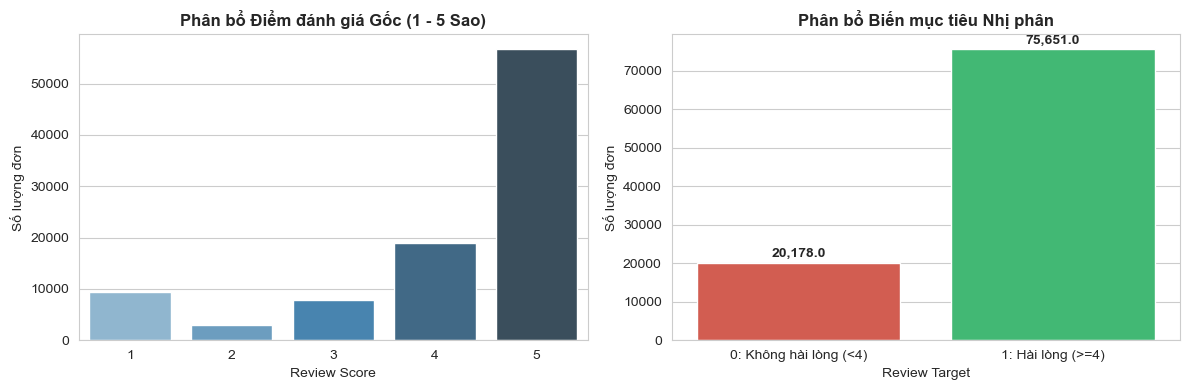

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ điểm review 1-5
sns.countplot(data=df_ml, x="review_score", palette="Blues_d", ax=axes[0])
axes[0].set_title("Phân bổ Điểm đánh giá Gốc (1 - 5 Sao)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Số lượng đơn")

# Biểu đồ nhãn mục tiêu nhị phân
ax2 = sns.countplot(data=df_ml, x="review_target", palette=["#e74c3c", "#2ecc71"], ax=axes[1])
axes[1].set_title("Phân bổ Biến mục tiêu Nhị phân", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Review Target")
axes[1].set_ylabel("Số lượng đơn")
axes[1].set_xticklabels(["0: Không hài lòng (<4)", "1: Hài lòng (>=4)"])
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f"{height:,}", (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


### Phân tích Quan hệ giữa Đặc trưng Số và Sự Hài lòng của Khách hàng


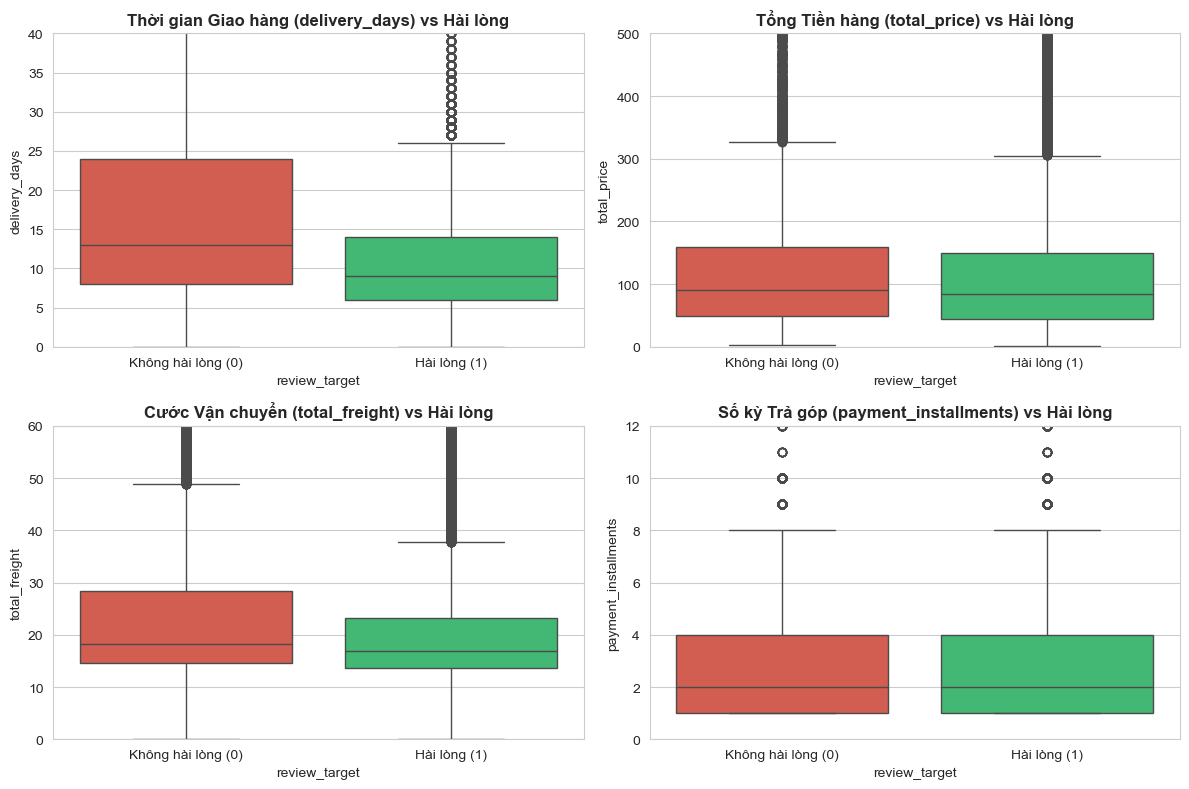

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df_ml, x="review_target", y="delivery_days", ax=axes[0, 0], palette=["#e74c3c", "#2ecc71"])
axes[0, 0].set_title("Thời gian Giao hàng (delivery_days) vs Hài lòng", fontweight='bold')
axes[0, 0].set_xticklabels(["Không hài lòng (0)", "Hài lòng (1)"])
axes[0, 0].set_ylim(0, 40)

sns.boxplot(data=df_ml, x="review_target", y="total_price", ax=axes[0, 1], palette=["#e74c3c", "#2ecc71"])
axes[0, 1].set_title("Tổng Tiền hàng (total_price) vs Hài lòng", fontweight='bold')
axes[0, 1].set_xticklabels(["Không hài lòng (0)", "Hài lòng (1)"])
axes[0, 1].set_ylim(0, 500)

sns.boxplot(data=df_ml, x="review_target", y="total_freight", ax=axes[1, 0], palette=["#e74c3c", "#2ecc71"])
axes[1, 0].set_title("Cước Vận chuyển (total_freight) vs Hài lòng", fontweight='bold')
axes[1, 0].set_xticklabels(["Không hài lòng (0)", "Hài lòng (1)"])
axes[1, 0].set_ylim(0, 60)

sns.boxplot(data=df_ml, x="review_target", y="payment_installments", ax=axes[1, 1], palette=["#e74c3c", "#2ecc71"])
axes[1, 1].set_title("Số kỳ Trả góp (payment_installments) vs Hài lòng", fontweight='bold')
axes[1, 1].set_xticklabels(["Không hài lòng (0)", "Hài lòng (1)"])
axes[1, 1].set_ylim(0, 12)

plt.tight_layout()
plt.show()


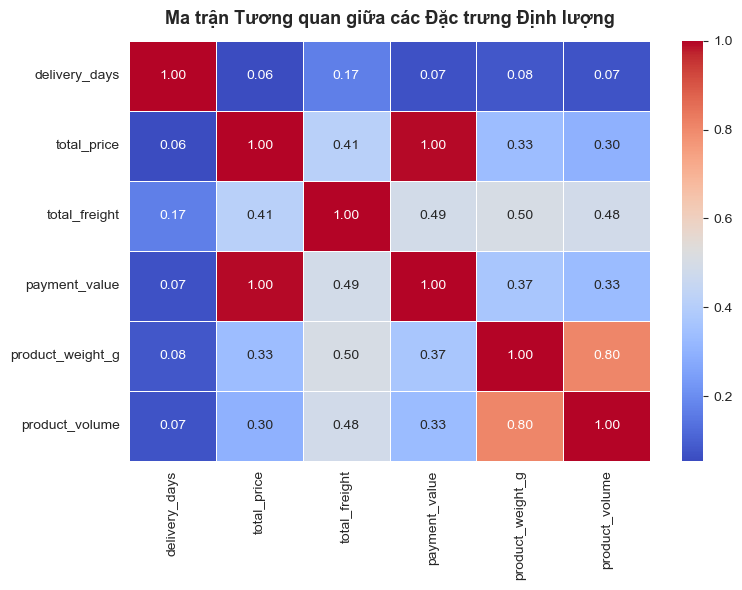

In [17]:
num_cols = ["delivery_days", "total_price", "total_freight", "payment_value", "product_weight_g", "product_volume"]
plt.figure(figsize=(8, 6))
sns.heatmap(df_ml[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Ma trận Tương quan giữa các Đặc trưng Định lượng", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 4. Tiền Xử Lý Dữ Liệu & Mã Hóa Biến Định Danh (One-Hot Encoding)
- Bỏ cột `order_id` (không mang ý nghĩa phân loại).
- Mã hóa One-Hot Encoding cho các biến định danh: `payment_type`, `customer_state`, `category_name`.
- Chuyển đổi các cột kiểu boolean sang integer (0, 1).


In [18]:
df_ml_model = df_ml.drop(columns=["order_id"])

cat_cols = ["payment_type", "customer_state", "category_name"]
df_ml_model = pd.get_dummies(df_ml_model, columns=cat_cols, drop_first=True)

bool_cols = df_ml_model.select_dtypes(include='bool').columns
df_ml_model[bool_cols] = df_ml_model[bool_cols].astype(int)

print(f"Kích thước ma trận đặc trưng sau One-Hot Encoding: {df_ml_model.shape}")
df_ml_model.head(3)


Kích thước ma trận đặc trưng sau One-Hot Encoding: (95829, 115)


,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,...,category_name_small_appliances,category_name_small_appliances_home_oven_and_coffee,category_name_small_appliances_kitchen_and_food_preparers,category_name_sports_leisure,category_name_stationery,category_name_tablets_printing_image,category_name_telephony,category_name_toys,category_name_unknown,category_name_watches_gifts
0,4,6.0,0,1,3,370.00,27.26,2,397.26,8,...,0,0,0,1,0,0,0,0,0,0
1,5,9.0,0,2,2,79.79,8.30,1,88.09,1,...,0,0,0,0,0,0,0,0,0,0
2,5,13.0,0,2,5,149.00,45.12,1,194.12,1,...,0,0,0,0,0,0,0,0,0,0


## 5. Phân Chia Tập Dữ Liệu & Xử Lý Mất Cân Bằng Lớp (SMOTE)
- Chia tập dữ liệu thành **Train (70%)** và **Test (30%)** với chiến lược phân tầng (`stratify=y`) để bảo toàn tỷ lệ nhãn.
- Áp dụng kỹ thuật **SMOTE (Synthetic Minority Over-sampling Technique)** trên tập huấn luyện để cân bằng số lượng mẫu giữa lớp `1` và lớp `0`, loại bỏ rủi ro mô hình bị thiên lệch (bias) về lớp đa số.


In [19]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_ml_model.drop(columns=["review_score", "review_target"])
y = df_ml_model["review_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tập Train ban đầu: {X_train.shape[0]:,} mẫu | Nhãn: {np.bincount(y_train)}")
print(f"Tập Test kiểm thử: {X_test.shape[0]:,} mẫu | Nhãn: {np.bincount(y_test)}")

oversample = SMOTE(random_state=42)
X_train_res, y_train_res = oversample.fit_resample(X_train, y_train)

print(f"\nTập Train sau SMOTE: {X_train_res.shape[0]:,} mẫu")
print(f"Phân bổ nhãn sau cân bằng: Lớp 0 = {np.bincount(y_train_res)[0]:,}, Lớp 1 = {np.bincount(y_train_res)[1]:,} (50% - 50%)")


Tập Train ban đầu: 67,080 mẫu | Nhãn: [14125 52955]
Tập Test kiểm thử: 28,749 mẫu | Nhãn: [ 6053 22696]



Tập Train sau SMOTE: 105,910 mẫu
Phân bổ nhãn sau cân bằng: Lớp 0 = 52,955, Lớp 1 = 52,955 (50% - 50%)


## 6. Huấn Luyện & Tối Ưu Hóa Số Lượng Cây (Random Forest Tuning)
Đánh giá độ chính xác của mô hình Random Forest Classifier theo số lượng cây (`n_estimators` từ 1 đến 50) sử dụng cơ chế `warm_start=True` và chạy song song trên tất cả các luồng CPU (`n_jobs=-1`).


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_tune = RandomForestClassifier(warm_start=True, random_state=42, n_jobs=-1)
acc = []
for i in range(1, 51):
    rf_tune.n_estimators = i
    rf_tune.fit(X_train_res, y_train_res)
    y_pred_tune = rf_tune.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred_tune))

best_trees = int(np.argmax(acc)) + 1
best_acc = acc[best_trees - 1]
print(f"Số lượng cây cho độ chính xác cao nhất: {best_trees} cây (Độ chính xác: {best_acc * 100:.2f}%)")


Số lượng cây cho độ chính xác cao nhất: 47 cây (Độ chính xác: 80.37%)


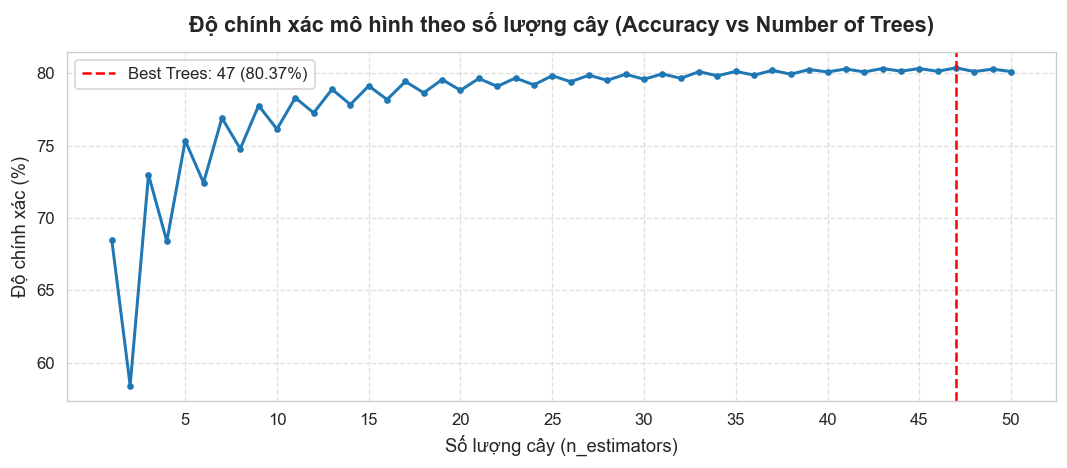

In [21]:
plt.figure(figsize=(9, 4), dpi=120)
plt.plot(range(1, 51), [a * 100 for a in acc], marker='o', markersize=3, color='#1f77b4', linewidth=1.8)
plt.axvline(x=best_trees, color='r', linestyle='--', linewidth=1.5, 
            label=f'Best Trees: {best_trees} ({best_acc * 100:.2f}%)')
plt.title("Độ chính xác mô hình theo số lượng cây (Accuracy vs Number of Trees)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Số lượng cây (n_estimators)", fontsize=11)
plt.ylabel("Độ chính xác (%)", fontsize=11)
plt.xticks(range(5, 55, 5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('../report/rf_accuracy_vs_trees.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Huấn Luyện Mô Hình Chuẩn & Đánh Giá Toàn Diện
Huấn luyện mô hình Random Forest với tham số tối ưu và đánh giá toàn diện thông qua:
1. **Báo cáo phân loại (Classification Report):** Precision, Recall, F1-score cho từng lớp.
2. **Ma trận nhầm lẫn (Confusion Matrix):** Số lượng dự đoán đúng/sai thực tế.
3. **Đường cong ROC & Chỉ số AUC:** Đo lường khả năng phân tách của mô hình.


In [22]:
rf_final = RandomForestClassifier(n_estimators=best_trees, random_state=42, n_jobs=-1)
rf_final.fit(X_train_res, y_train_res)
y_pred = rf_final.predict(X_test)

final_acc = accuracy_score(y_test, y_pred)
print(f"=== ĐỘ CHÍNH XÁC TOÀN CỤC (ACCURACY): {final_acc * 100:.2f}% ===\n")
print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred, target_names=["Không hài lòng (<4 sao)", "Hài lòng (>=4 sao)"]))


=== ĐỘ CHÍNH XÁC TOÀN CỤC (ACCURACY): 80.37% ===

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
                         precision    recall  f1-score   support

Không hài lòng (<4 sao)       0.57      0.29      0.39      6053
     Hài lòng (>=4 sao)       0.83      0.94      0.88     22696

               accuracy                           0.80     28749
              macro avg       0.70      0.62      0.63     28749
           weighted avg       0.78      0.80      0.78     28749



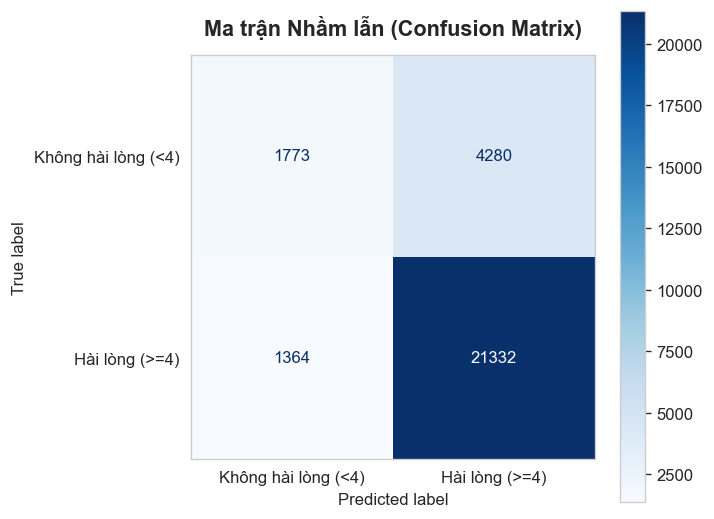

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Không hài lòng (<4)", "Hài lòng (>=4)"]
)
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Ma trận Nhầm lẫn (Confusion Matrix)", fontsize=13, fontweight='bold', pad=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('../report/rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


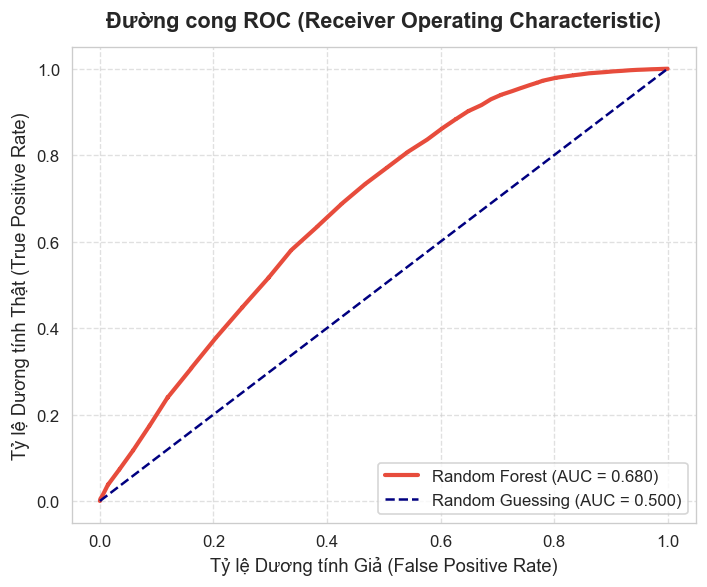

In [24]:
from sklearn.metrics import roc_auc_score, roc_curve

y_probabilities = rf_final.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probabilities)
auc_score = roc_auc_score(y_test, y_probabilities)

plt.figure(figsize=(6, 5), dpi=120)
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5, label='Random Guessing (AUC = 0.500)')
plt.title("Đường cong ROC (Receiver Operating Characteristic)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Tỷ lệ Dương tính Giả (False Positive Rate)", fontsize=11)
plt.ylabel("Tỷ lệ Dương tính Thật (True Positive Rate)", fontsize=11)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../report/rf_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Phân Tích Độ Quan Trọng Của Đặc Trưng (Feature Importance)
Xác định những yếu tố nào có ảnh hưởng mạnh nhất đến việc khách hàng chấm điểm cao hay thấp.


In [25]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

top15 = importance.head(15)
print("=== TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT ===")
print(top15.to_string(index=False))


=== TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT ===
                         feature  importance
                   delivery_days    0.127962
                   total_freight    0.071272
                   payment_value    0.061730
                  product_volume    0.060573
                     total_price    0.059322
                product_weight_g    0.057064
        customer_state_São Paulo    0.053153
                purchase_weekday    0.046124
                  purchase_month    0.045254
            payment_installments    0.039121
     customer_state_Minas Gerais    0.034564
   customer_state_Rio de Janeiro    0.030867
customer_state_Rio Grande do Sul    0.023456
           customer_state_Paraná    0.019514
                         is_late    0.018893


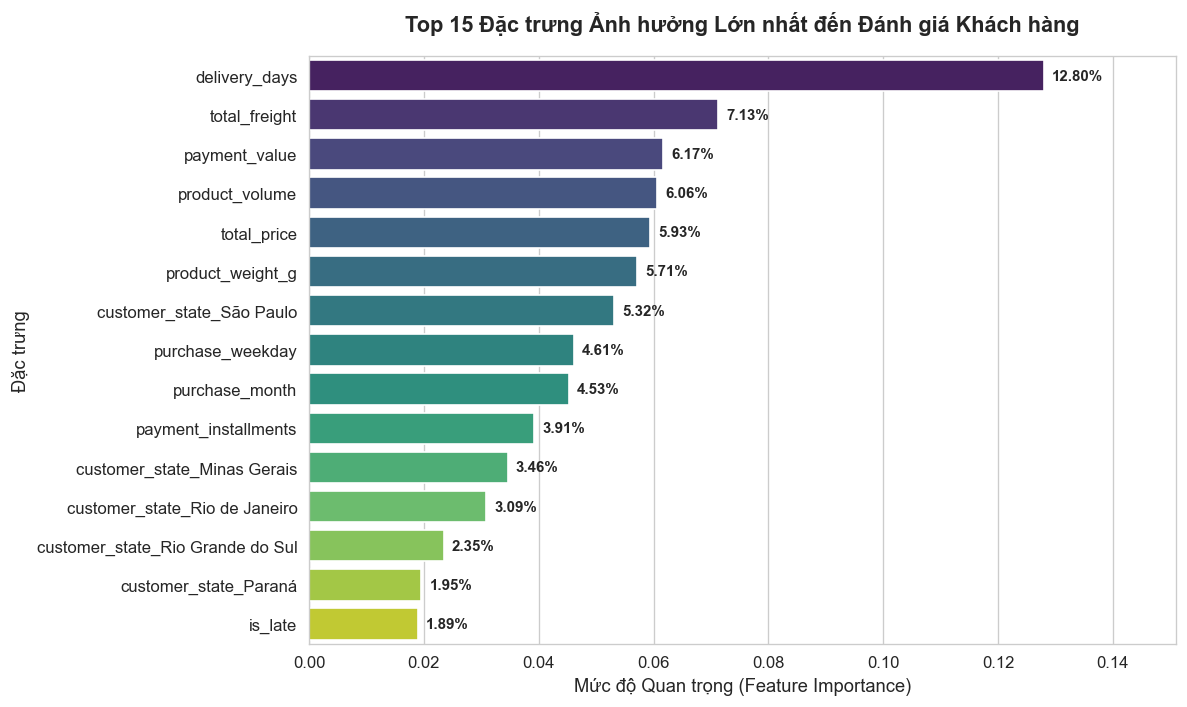

In [26]:
plt.figure(figsize=(10, 6), dpi=120)
ax = sns.barplot(data=top15, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Đặc trưng Ảnh hưởng Lớn nhất đến Đánh giá Khách hàng", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Mức độ Quan trọng (Feature Importance)", fontsize=11)
plt.ylabel("Đặc trưng", fontsize=11)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width * 100:.2f}%", (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                    fontweight='bold', fontsize=9)
plt.xlim(0, top15['importance'].max() * 1.18)
plt.tight_layout()
plt.savefig('../report/rf_top15_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Tổng Kết & Đề Xuất Chiến Lược Vận Hành (Business Insights & Recommendations)

###  1. Phát hiện Then chốt từ Mô hình (Key Findings):
1. **Thời gian giao hàng (`delivery_days`) là yếu tố chi phối số 1 (~13% độ quan trọng):**
   - Tốc độ giao hàng là thước đo lớn nhất quyết định việc khách hàng cho 5 sao hay 1 sao. Khi đơn hàng được giao nhanh, khách hàng sẵn sàng bỏ qua các thiếu sót nhỏ khác. Ngược lại, giao chậm và trễ hạn (`is_late`) là nguyên nhân hàng đầu dẫn đến đánh giá tiêu cực.
2. **Chi phí và giá trị giao dịch (`total_freight`, `payment_value`, `total_price`):**
   - Cước phí vận chuyển chiếm vị trí số 2 về mức độ ảnh hưởng. Phí ship quá cao so với giá trị sản phẩm làm giảm mạnh sự hài lòng.
3. **Đặc tính sản phẩm (`product_volume`, `product_weight_g`):**
   - Các sản phẩm cồng kềnh, nặng thường có rủi ro móp méo, trầy xước trong khâu vận chuyển chặng cuối (last-mile delivery), dễ phát sinh khiếu nại.

---

### 🚀 2. Đề Xuất Hành Động Thực Tiễn (Actionable Strategies):
- **Tối ưu hóa Mạng lưới Vận chuyển (Logistics Optimization):**
  - Giám sát chặt chẽ SLA giao hàng của các đơn vị vận chuyển tại các tuyến liên bang xa.
  - Tự động cảnh báo đơn hàng có nguy cơ trễ hạn để bộ phận CSKH chủ động thông báo trước cho khách hàng kèm lời xin lỗi hoặc voucher giảm giá.
- **Chiến lược Trợ giá Vận chuyển (Freight Subsidies):**
  - Thiết lập các chương trình Freeship Extra hoặc đồng giá vận chuyển cho các đơn hàng có phí ship cao để kích thích sự hài lòng và tăng tỷ lệ chuyển đổi.
- **Tiêu chuẩn Đóng gói cho Hàng Cồng Kềnh:**
  - Siết chặt quy trình đóng gói chèn xốp đối với các danh mục hàng có thể tích (`product_volume`) và trọng lượng lớn nhằm giảm thiểu tỷ lệ hoàn hàng và đánh giá 1 sao do hư hỏng vận chuyển.
